# 2. Exploratory Data Analysis
**Dataset:** Customer Churn (Telecom) — `data/cleaned_data.csv`
**Goal:** Understand distributions, relationships, and churn patterns to guide deeper analysis.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../data/cleaned_data.csv')
df.shape

(500, 11)

In [2]:
df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn,PaperlessBilling_Flag,AvgMonthlySpend
0,C00001,6,64,1540,One year,Credit Card,No,1,0,0,256.67
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0,1,83.48
2,C00003,27,31,1455,Two year,Credit Card,No,1,0,0,53.89
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0,0,134.91
4,C00005,16,185,1023,One year,Electronic Check,No,1,0,0,63.94


## 2.1 Target Variable — Churn

Overall churn rate: 10.6%


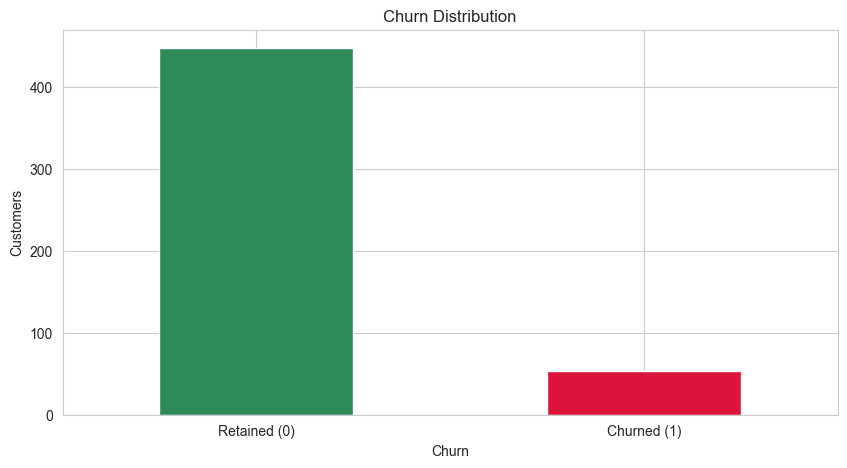

In [16]:
churn_rate = df['Churn'].mean()
print(f"Overall churn rate: {churn_rate:.1%}")

ax = df['Churn'].value_counts().plot(kind='bar', color=['seagreen', 'crimson'])
ax.set_xticklabels(['Retained (0)', 'Churned (1)'], rotation=0)
ax.set_title('Churn Distribution')
ax.set_ylabel('Customers')
folder_name = "graphs"
os.makedirs(f"../{folder_name}", exist_ok=True)
plt.savefig(f"../{folder_name}/churn_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

**Pattern:** Class imbalance — churners are a minority. Keep this in mind for any modeling later (accuracy alone would be misleading).

## 2.2 Numeric Feature Distributions

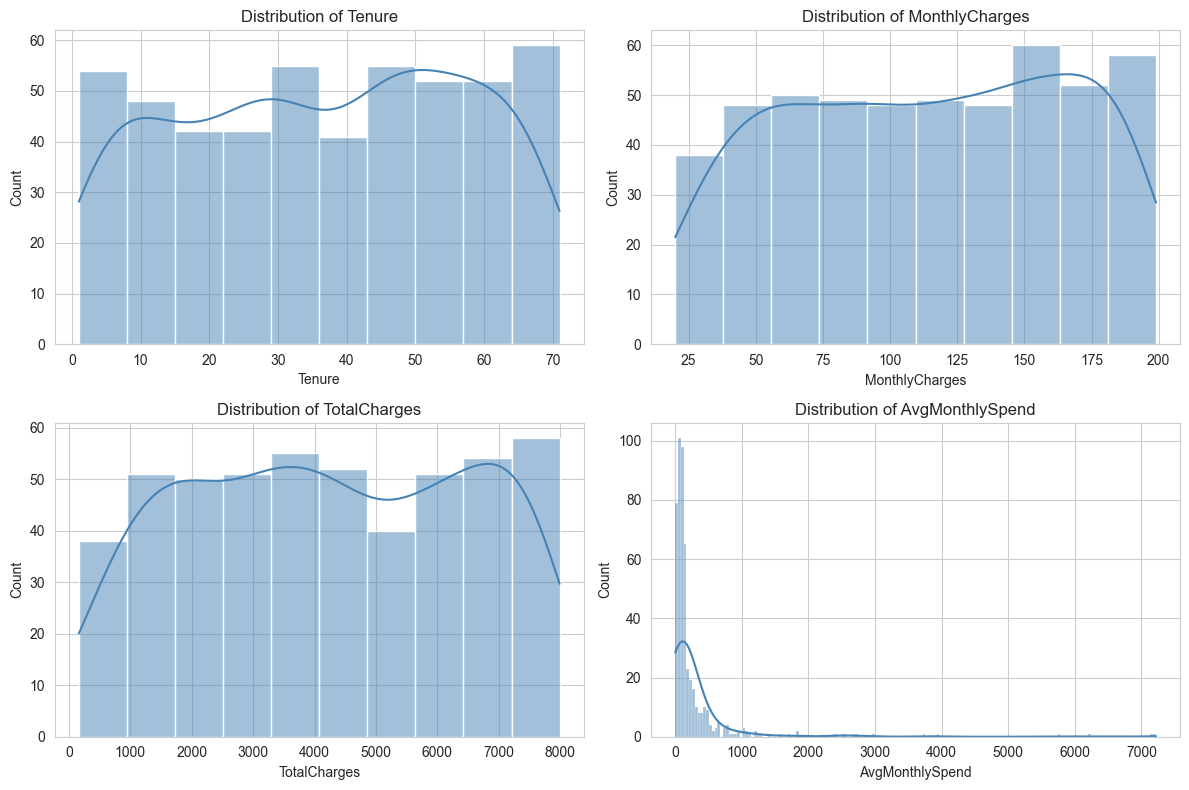

In [17]:
num_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig(f"../{folder_name}/numeric_distributions.png", dpi=150)
plt.show()

In [18]:
df[num_cols].describe()

,Tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend
count,500.000000,500.000000,500.000000,500.000000
mean,36.532000,113.636000,4237.882000,300.539300
std,20.667057,51.799903,2260.619837,723.833979
min,1.000000,20.000000,159.000000,3.110000
25%,19.000000,67.000000,2237.250000,64.432500
50%,37.000000,115.000000,4182.500000,115.600000
75%,54.000000,158.000000,6266.750000,232.170000
max,71.000000,199.000000,7992.000000,7217.000000


## 2.3 Categorical Feature Breakdown

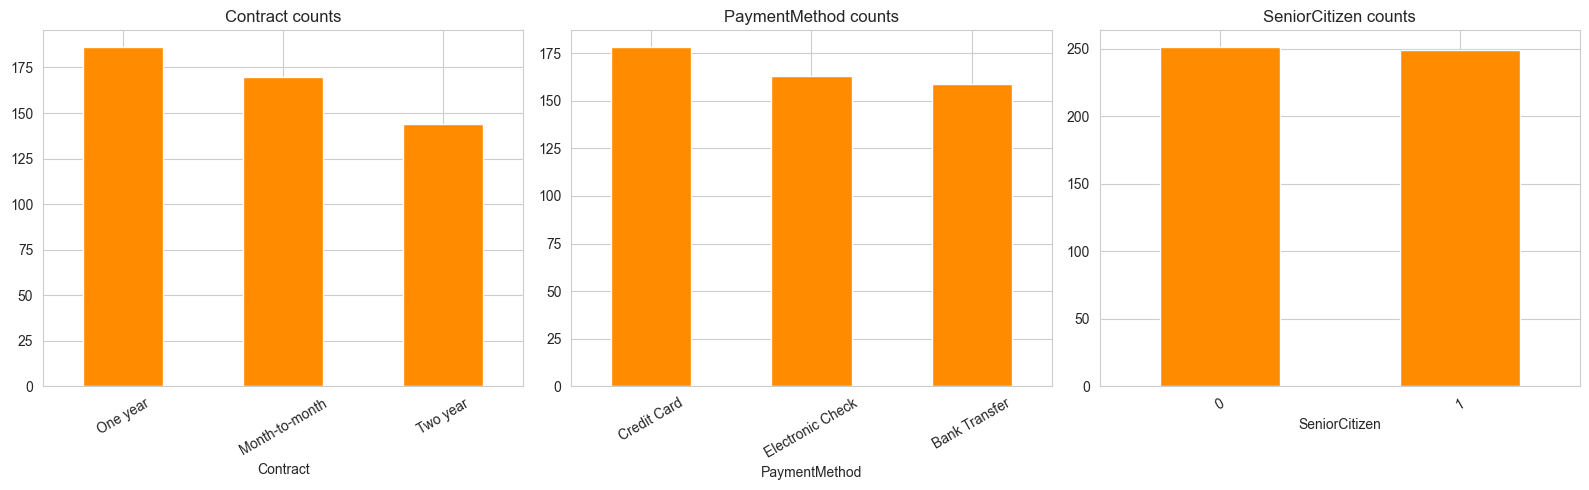

In [19]:
cat_cols = ['Contract', 'PaymentMethod', 'SeniorCitizen']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color='darkorange')
    ax.set_title(f'{col} counts')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(f"../{folder_name}/categorical_counts.png", dpi=150)
plt.show()

## 2.4 Churn Rate by Segment (key business patterns)

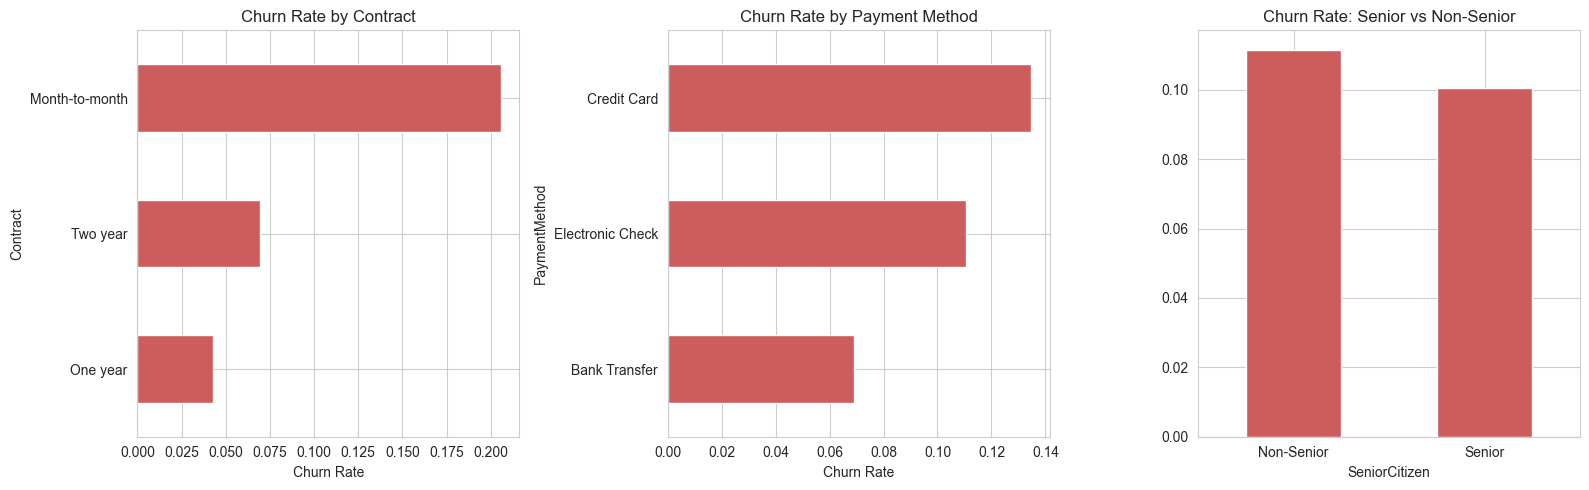

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df.groupby('Contract')['Churn'].mean().sort_values().plot(kind='barh', ax=axes[0], color='indianred')
axes[0].set_title('Churn Rate by Contract')
axes[0].set_xlabel('Churn Rate')

df.groupby('PaymentMethod')['Churn'].mean().sort_values().plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title('Churn Rate by Payment Method')
axes[1].set_xlabel('Churn Rate')

df.groupby('SeniorCitizen')['Churn'].mean().plot(kind='bar', ax=axes[2], color='indianred')
axes[2].set_title('Churn Rate: Senior vs Non-Senior')
axes[2].set_xticklabels(['Non-Senior', 'Senior'], rotation=0)

plt.tight_layout()
plt.savefig(f"../{folder_name}/churn_by_segment.png", dpi=150)
plt.show()

## 2.5 Numeric Features vs Churn

C:\Users\karti\AppData\Local\Temp\ipykernel_27980\1746410571.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=ax, palette=['seagreen', 'crimson'])
C:\Users\karti\AppData\Local\Temp\ipykernel_27980\1746410571.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Retained', 'Churned'])
C:\Users\karti\AppData\Local\Temp\ipykernel_27980\1746410571.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=ax, palette=['seagreen', 'crimson'])
C:\Users\karti\AppData\Local\Temp\ipykernel_27980\1746410571.py:4: UserWarning: set_ticklabels() 

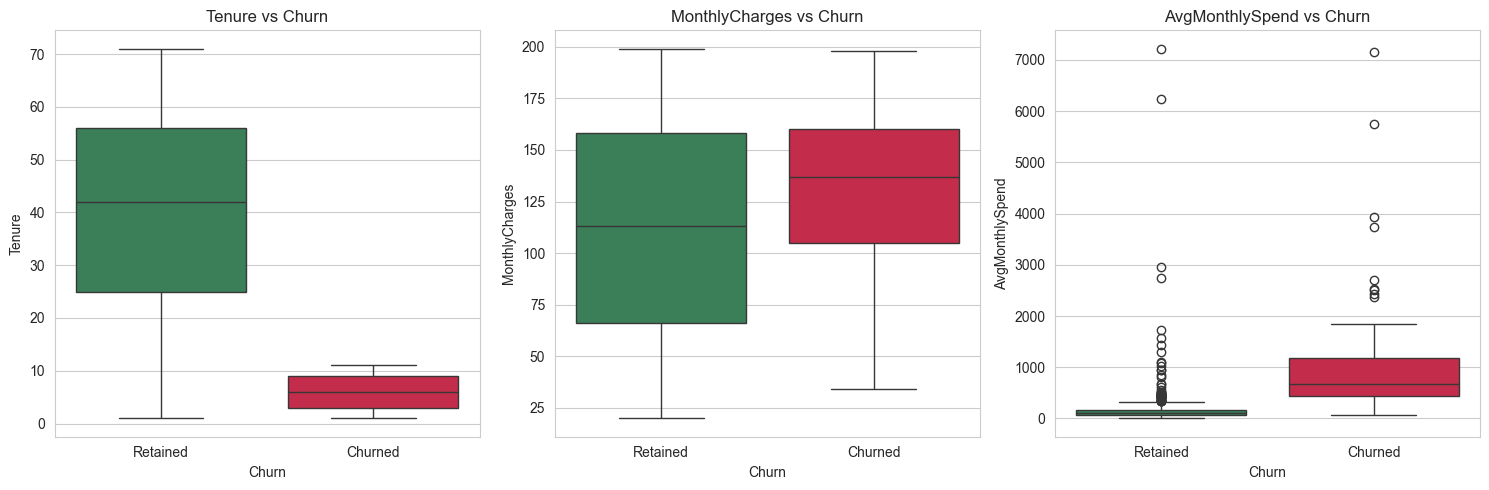

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['Tenure', 'MonthlyCharges', 'AvgMonthlySpend']):
    sns.boxplot(data=df, x='Churn', y=col, ax=ax, palette=['seagreen', 'crimson'])
    ax.set_xticklabels(['Retained', 'Churned'])
    ax.set_title(f'{col} vs Churn')
plt.tight_layout()
plt.savefig(f"../{folder_name}/numeric_vs_churn.png", dpi=150)
plt.show()

## 2.6 Correlation Analysis

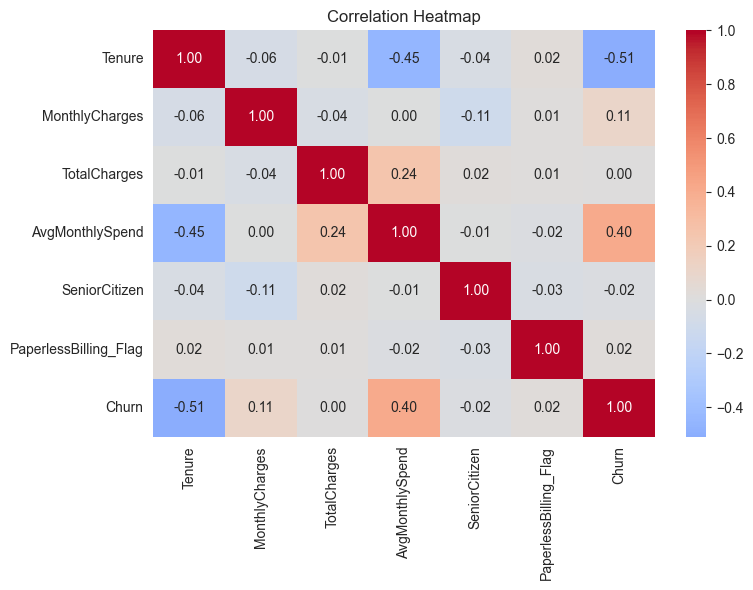

In [22]:
corr_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend',
             'SeniorCitizen', 'PaperlessBilling_Flag', 'Churn']
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(f"../{folder_name}/correlation_heatmap.png", dpi=150)
plt.show()

In [23]:
print("Correlation with Churn (sorted):")
print(corr['Churn'].drop('Churn').sort_values(ascending=False))

Correlation with Churn (sorted):
AvgMonthlySpend          0.404714
MonthlyCharges           0.107381
PaperlessBilling_Flag    0.016145
TotalCharges             0.004250
SeniorCitizen           -0.018114
Tenure                  -0.509208
Name: Churn, dtype: float64


## 2.7 Bivariate: Tenure vs MonthlyCharges colored by Churn

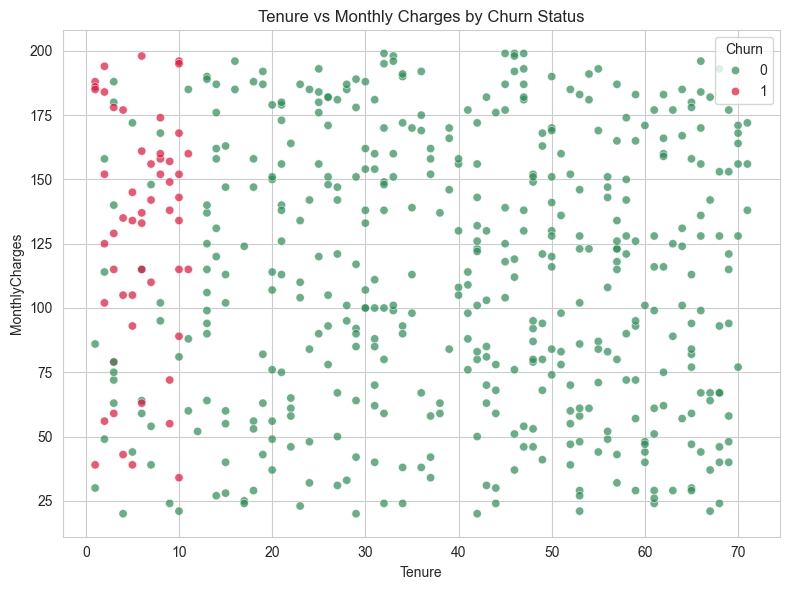

In [24]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Tenure', y='MonthlyCharges', hue='Churn',
                palette=['seagreen', 'crimson'], alpha=0.7)
plt.title('Tenure vs Monthly Charges by Churn Status')
plt.tight_layout()
plt.savefig(f"../{folder_name}/tenure_vs_charges_scatter.png", dpi=150)
plt.show()

## 2.8 Key Patterns Identified

1. **Contract type is the strongest churn driver** — month-to-month customers churn far more than one/two-year contract holders.
2. **Tenure is inversely related to churn** — newer customers churn more; loyalty builds retention.
3. **Monthly charges are mildly positively correlated with churn** — pricier plans see marginally higher churn.
4. **Senior citizens churn at a somewhat higher rate** than non-seniors.
5. **Payment method shows some variation** in churn rate, worth testing statistically in the next notebook.

These patterns motivate the hypothesis tests and modeling done in `3_analysis.ipynb`.
